<a href="https://colab.research.google.com/github/Swaraj-sj2000/Machine-leaning-projects/blob/main/tabular_and_text_ingestion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("puneet6060/intel-image-classification")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'intel-image-classification' dataset.
Path to dataset files: /kaggle/input/intel-image-classification


In [3]:
path_dataset="/kaggle/input/intel-image-classification"

In [4]:
import os
for dir in os.listdir(path_dataset):
    print(dir)
    print(os.listdir(path=os.path.join(path,dir)))

seg_train
['seg_train']
seg_pred
['seg_pred']
seg_test
['seg_test']


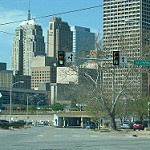

In [5]:
import cv2
from google.colab.patches import cv2_imshow
img=cv2.imread("/kaggle/input/intel-image-classification/seg_test/seg_test/buildings/20060.jpg")
cv2_imshow(img)

In [6]:
train_ds=tf.keras.preprocessing.image_dataset_from_directory(
    directory="/kaggle/input/intel-image-classification/seg_train/seg_train",
    labels='inferred',
    label_mode='int',
    class_names=['buildings','forest','glacier','mountain','sea','street'],
    color_mode='grayscale',
    batch_size=32,
    image_size=(256,256),
    shuffle=True,
    seed=42,
    validation_split=0.1,
    subset='training',
    verbose=True)

test_ds=tf.keras.preprocessing.image_dataset_from_directory(
    directory="/kaggle/input/intel-image-classification/seg_test/seg_test",
    labels="inferred",
    label_mode='int',
    class_names=["buildings","forest","glacier","mountain","sea","street"],
    color_mode='grayscale',
    batch_size=32,
    image_size=(256,256),
    shuffle=True,
    seed=42,
    verbose=True
    )

Found 14034 files belonging to 6 classes.
Using 12631 files for training.
Found 3000 files belonging to 6 classes.


In [7]:
import tensorflow as tf
data=tf.random.uniform(shape=(20,),minval=0,maxval=100,dtype=tf.int32)


In [8]:
print(data)

tf.Tensor([80 86 27 28 16 78 10 29 60 52 76 87 73 17 63  1  9 51 16 11], shape=(20,), dtype=int32)


In [9]:
dataset=tf.data.Dataset.from_tensor_slices(data)
df1=dataset.batch(3)


In [10]:
itr=iter(df1)
b1=next(itr)

In [11]:
for b in b1:
  print(b)

tf.Tensor(80, shape=(), dtype=int32)
tf.Tensor(86, shape=(), dtype=int32)
tf.Tensor(27, shape=(), dtype=int32)


In [12]:
df2=df1.map(lambda x:(x,x**2))

In [13]:
b2=df2.take(1)
for a,b in b2:
  print(a,b)

tf.Tensor([80 86 27], shape=(3,), dtype=int32) tf.Tensor([6400 7396  729], shape=(3,), dtype=int32)


In [14]:
df3=dataset.batch(3).map(lambda x:x**2,num_parallel_calls=tf.data.AUTOTUNE)


In [15]:
for b in iter(df3):
  print(b)


tf.Tensor([6400 7396  729], shape=(3,), dtype=int32)
tf.Tensor([ 784  256 6084], shape=(3,), dtype=int32)
tf.Tensor([ 100  841 3600], shape=(3,), dtype=int32)
tf.Tensor([2704 5776 7569], shape=(3,), dtype=int32)
tf.Tensor([5329  289 3969], shape=(3,), dtype=int32)
tf.Tensor([   1   81 2601], shape=(3,), dtype=int32)
tf.Tensor([256 121], shape=(2,), dtype=int32)


In [16]:
df_list=tf.data.Dataset.list_files("/kaggle/input/intel-image-classification/seg_train/seg_train/*/*.jpg")

In [17]:
itr=iter(df_list)
b1=next(itr)

In [18]:
df_train=df_list.interleave(
    lambda x:tf.data.TextLineDataset(x),
    cycle_length=4,
    num_parallel_calls=tf.data.AUTOTUNE)


In [19]:
import pandas as pd
import kagglehub
from kagglehub import KaggleDatasetAdapter

df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "yasserh/wine-quality-dataset",
 "WineQT.csv",

)

/tmp/ipykernel_6895/3848654680.py:5: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'wine-quality-dataset' dataset.


In [20]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [21]:
import numpy as np
x=df.drop(columns=["quality"]).values.astype(np.float32)
y=df['quality'].values.astype(np.int64)
print(x.shape,y.shape)

(1143, 12) (1143,)


In [22]:
def _float_features(value):
  return tf.train.Feature(
      float_list=tf.train.FloatList(value=value)
  )

def _int64_features(value):
  return tf.train.Feature(
      int64_list=tf.train.Int64List(value=[value])
  )

In [23]:
def serialize_example(features, label):
    feature = {
        "features": _float_features(features),
        "label": _int64_features(label)
    }

    example = tf.train.Example(
        features=tf.train.Features(feature=feature)
    )

    return example.SerializeToString()

In [24]:
example=serialize_example(x[0],y[0])
print(type(example))

<class 'bytes'>


In [25]:
x[0]

array([ 7.4   ,  0.7   ,  0.    ,  1.9   ,  0.076 , 11.    , 34.    ,
        0.9978,  3.51  ,  0.56  ,  9.4   ,  0.    ], dtype=float32)

In [26]:
y[0]

np.int64(5)

In [27]:
with tf.io.TFRecordWriter("wine.tfrecord") as writer:
  for i in range(len(x)):
    example=serialize_example(x[i],y[i])
    writer.write(example)

In [28]:
import os
print(os.path.getsize("wine.tfrecord"))

114300


In [29]:
feature_description={
    'features':tf.io.FixedLenFeature([x.shape[1]],tf.float32),
    'label':tf.io.FixedLenFeature([],tf.int64)

    }

In [30]:
def parse_example(example_proto):
  parsed=tf.io.parse_single_example(
      example_proto,
      feature_description
  )

  return parsed['features'],parsed['label']

In [31]:
dataset = tf.data.TFRecordDataset("wine.tfrecord")

dataset = dataset.map(
    parse_example,
    num_parallel_calls=tf.data.AUTOTUNE
)

dataset = dataset.batch(32)
dataset = dataset.prefetch(tf.data.AUTOTUNE)

In [32]:
for x, y in dataset.take(1):
    print(x.shape)
    print(y.shape)

(32, 12)
(32,)


In [33]:
import tensorflow as tf
texts=["Hello world",
    "This is a test",
    "Hi there"]

vectorizer=tf.keras.layers.TextVectorization(
    max_tokens=1000,
    output_mode='int',
    output_sequence_length=5
)


In [34]:
vectorizer.adapt(texts)
output=vectorizer(texts)
print(output)

tf.Tensor(
[[8 2 0 0 0]
 [3 6 9 5 0]
 [7 4 0 0 0]], shape=(3, 5), dtype=int64)


In [35]:
vectorizer.get_vocabulary()

['',
 '[UNK]',
 np.str_('world'),
 np.str_('this'),
 np.str_('there'),
 np.str_('test'),
 np.str_('is'),
 np.str_('hi'),
 np.str_('hello'),
 np.str_('a')]

In [36]:
dataset=tf.data.Dataset.from_tensor_slices(texts).map(lambda x:vectorizer(x)).batch(2).prefetch(tf.data.AUTOTUNE)

In [37]:
import tensorflow_datasets as tfds

dataset, info = tfds.load(
    "imdb_reviews",
    with_info=True,
    as_supervised=True
)

train_data, test_data = dataset["train"], dataset["test"]

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/imdb_reviews/plain_text/incomplete.PXIAH0_1.0.0/imdb_reviews-train.tfrecor…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/imdb_reviews/plain_text/incomplete.PXIAH0_1.0.0/imdb_reviews-test.tfrecord…

Generating unsupervised examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/imdb_reviews/plain_text/incomplete.PXIAH0_1.0.0/imdb_reviews-unsupervised.…

Dataset imdb_reviews downloaded and prepared to /root/tensorflow_datasets/imdb_reviews/plain_text/1.0.0. Subsequent calls will reuse this data.


In [38]:
for text,label in train_data.take(1):
  print(text,"\n",label)

tf.Tensor(b"This was an absolutely terrible movie. Don't be lured in by Christopher Walken or Michael Ironside. Both are great actors, but this must simply be their worst role in history. Even their great acting could not redeem this movie's ridiculous storyline. This movie is an early nineties US propaganda piece. The most pathetic scenes were those when the Columbian rebels were making their cases for revolutions. Maria Conchita Alonso appeared phony, and her pseudo-love affair with Walken was nothing but a pathetic emotional plug in a movie that was devoid of any real meaning. I am disappointed that there are movies like this, ruining actor's like Christopher Walken's good name. I could barely sit through it.", shape=(), dtype=string) 
 tf.Tensor(0, shape=(), dtype=int64)


In [39]:
vectorizer=tf.keras.layers.TextVectorization(
    max_tokens=100000,
    output_mode='int',
    output_sequence_length=200
)


In [40]:
vectorizer = tf.keras.layers.TextVectorization(
    max_tokens=100000,
    output_mode="int",
    output_sequence_length=200
)

train_text = train_data.map(lambda text, label: text)

vectorizer.adapt(train_text)

def vectorize(text, label):
    text = vectorizer(text)
    return text, label

train_ds = train_data.map(vectorize).shuffle(1000).batch(32).prefetch(tf.data.AUTOTUNE)

test_ds = test_data.map(vectorize).batch(32).prefetch(tf.data.AUTOTUNE)

In [41]:
for x,y in train_ds.take(1):
  print(x.shape)
  print(y.shape)

(32, 200)
(32,)


In [42]:
print(len(vectorizer.get_vocabulary()))

100000


In [43]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

MAX_LENGTH=128

def hf_tokenize(text,label):
  encoded = tokenizer(
      text.numpy().decode('utf-8'),
      padding="max_length",
      truncation=True,
      max_length=MAX_LENGTH
  )
  return (encoded['input_ids'],
          encoded['attention_mask'],
          label)


def tf_tokenize(text,label):
  input_ids,attention_mask,label=tf.py_function(
      hf_tokenize,
      [text,label],
      [tf.int32,tf.int32,tf.int64]
  )
  input_ids.set_shape([MAX_LENGTH])
  attention_mask.set_shape([MAX_LENGTH])
  label.set_shape([])

  return {
      'input_ids':input_ids,
      'attention_mask':attention_mask,

  },label





/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [44]:
BATCH_SIZE=32

train_ds=train_data.map(tf_tokenize,num_parallel_calls=tf.data.AUTOTUNE).shuffle(10000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_ds=test_data.map(tf_tokenize,num_parallel_calls=tf.data.AUTOTUNE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


In [45]:
for x, y in train_ds.take(1):
    for key, value in x.items():
        print(key, value.shape)

    print("Labels:", y.shape)

input_ids (32, 128)
attention_mask (32, 128)
Labels: (32,)


In [46]:
def _int64_feature(values):
  return tf.train.Feature(
      int64_list=tf.train.Int64List(value=values)
  )

def serialize_example(input_ids,attention_masks,label):
  feature={
      'input_ids':_int64_feature(input_ids),
      'attention_mask':_int64_feature(attention_masks),
      'label':_int64_feature([label])
  }

  example=tf.train.Example(
      features=tf.train.Features(feature=feature))

  return example.SerializeToString()


In [47]:
with tf.io.TFRecordWriter("imdb_train.tfrecord") as writer:
    for text, label in train_data:
        encoded = tokenizer(
            text.numpy().decode("utf-8"),
            padding="max_length",
            truncation=True,
            max_length=MAX_LENGTH
        )

        serialized_example = serialize_example(
            encoded["input_ids"],
            encoded["attention_mask"],
            int(label.numpy())
        )

        writer.write(serialized_example)

In [48]:
import os
print(os.path.getsize("imdb_train.tfrecord"))

11717875


In [49]:
feature_description={
    'input_ids':tf.io.FixedLenFeature([MAX_LENGTH],tf.int64),
    'attention_mask':tf.io.FixedLenFeature([MAX_LENGTH],tf.int64),
    'label':tf.io.FixedLenFeature([],tf.int64),
    }

def parse_example(example_proto):
  parsed=tf.io.parse_single_example(
      example_proto,
      feature_description
  )

  label=parsed.pop('label')
  return parsed,label

train_ds_out=tf.data.TFRecordDataset("imdb_train.tfrecord")
train_ds_out=train_ds_out.map(parse_example,num_parallel_calls=tf.data.AUTOTUNE).shuffle(10000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)



In [50]:
for x,y in train_ds_out.take(1):
  print(x.keys())
  print(x['input_ids'].shape)
  print(x['attention_mask'].shape)
  print(y.shape)

dict_keys(['attention_mask', 'input_ids'])
(32, 128)
(32, 128)
(32,)


In [51]:
NUM_SHARDS=10
writers=[tf.io.TFRecordWriter(f"train-{i:03d}.tfrecord") for i in range(NUM_SHARDS)]

for idx,(text,label) in enumerate(train_data):
  encoded=tokenizer(
      text.numpy().decode('utf-8'),
      padding='max_length',
      truncation=True,
      max_length=MAX_LENGTH
  )

  serialized_example=serialize_example(
      encoded['input_ids'],
      encoded['attention_mask'],
      int(label.numpy())
  )

  shard_idx=idx%NUM_SHARDS
  writers[shard_idx].write(serialized_example)

for writer in writers:
  writer.close()



In [52]:
from datasets import load_dataset
dataset=load_dataset("yelp_polarity")

README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/256M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/17.7M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/560000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/38000 [00:00<?, ? examples/s]

In [53]:
train_ds,test_ds=dataset['train'],dataset['test']


In [54]:
print(train_ds.shape,test_ds.shape)

(560000, 2) (38000, 2)


In [55]:
sample=train_ds[:5]
for text, label in zip(sample["text"], sample["label"]):
    print(text)
    print(label)
    print()

Unfortunately, the frustration of being Dr. Goldberg's patient is a repeat of the experience I've had with so many other doctors in NYC -- good doctor, terrible staff.  It seems that his staff simply never answers the phone.  It usually takes 2 hours of repeated calling to get an answer.  Who has time for that or wants to deal with it?  I have run into this problem with many other doctors and I just don't get it.  You have office workers, you have patients with medical needs, why isn't anyone answering the phone?  It's incomprehensible and not work the aggravation.  It's with regret that I feel that I have to give Dr. Goldberg 2 stars.
0

Been going to Dr. Goldberg for over 10 years. I think I was one of his 1st patients when he started at MHMG. He's been great over the years and is really all about the big picture. It is because of him, not my now former gyn Dr. Markoff, that I found out I have fibroids. He explores all options with you and is very patient and understanding. He doesn'

In [56]:
import tensorflow as tf
train_tf=train_ds.to_tf_dataset(
    columns='text',
    label_cols='label',
    shuffle=False,
    batch_size=32
)

In [57]:
for text,label in train_tf.take(1):
  print(text[0])
  print(label[0])


tf.Tensor(b"Unfortunately, the frustration of being Dr. Goldberg's patient is a repeat of the experience I've had with so many other doctors in NYC -- good doctor, terrible staff.  It seems that his staff simply never answers the phone.  It usually takes 2 hours of repeated calling to get an answer.  Who has time for that or wants to deal with it?  I have run into this problem with many other doctors and I just don't get it.  You have office workers, you have patients with medical needs, why isn't anyone answering the phone?  It's incomprehensible and not work the aggravation.  It's with regret that I feel that I have to give Dr. Goldberg 2 stars.", shape=(), dtype=string)
tf.Tensor(0, shape=(), dtype=int64)


In [58]:
def get_length(text,label):
  return tf.shape(tf.strings.split(text))

for text,label in train_tf.take(1):
  print(get_length(text,label))




<DynamicRaggedShape lengths=[32, (115, 97, 211, 193, 75, 60, 217, 108, 187, 73, 50, 22, 712, 81, 19, 35, 63, 151, 48, 62, 39, 726, 1, 35, 631, 46, 44, 55, 98, 45, 139, 60)] num_row_partitions=1>


In [59]:
length_ds=train_tf.unbatch().map(get_length,num_parallel_calls=tf.data.AUTOTUNE)

In [60]:
for item in length_ds.take(1):
  print(item)

tf.Tensor([115], shape=(1,), dtype=int32)


In [61]:
max_len=length_ds.reduce(
    tf.constant(0,dtype=tf.int32),
    lambda state,x:tf.maximum(state,x))
print(max_len)

tf.Tensor([1052], shape=(1,), dtype=int32)


In [62]:
min_length=length_ds.reduce(
    tf.constant(2000,dtype=tf.int32),
                lambda state,x:tf.minimum(state,x))



In [63]:
print(min_length.numpy())

[1]


In [64]:
short_rev=train_tf.unbatch().filter(
    lambda text,label:tf.equal(tf.shape(tf.strings.split(text))[0],tf.squeeze(min_length)))
shp=short_rev.reduce(tf.constant(0,dtype=tf.int32),lambda state,_:state+1)
print(shp.numpy())

302


In [65]:
label_ds=train_tf.unbatch().map(lambda text,label:label)

def count_label(state,label):
  neg,pos=state
  neg+=tf.cast(label==0,tf.int32)
  pos+=tf.cast(label==1,tf.int32)
  return neg,pos

class_counts=label_ds.reduce((tf.constant(0,tf.int32),
                              tf.constant(0,tf.int32)),
                             count_label)
print(class_counts)

(<tf.Tensor: shape=(), dtype=int32, numpy=280000>, <tf.Tensor: shape=(), dtype=int32, numpy=280000>)


In [77]:
print(class_counts[0])

tf.Tensor(280000, shape=(), dtype=int32)


In [66]:
lengths=list(length_ds.as_numpy_iterator())

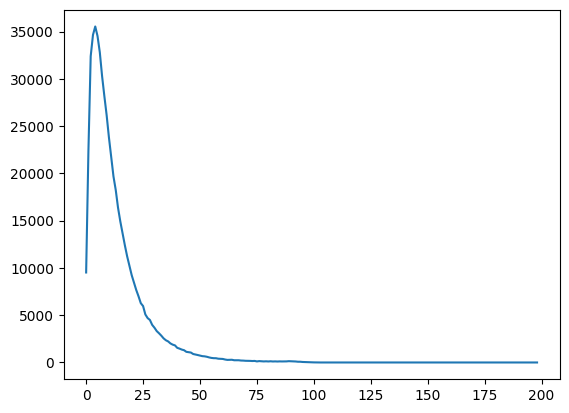

In [67]:
bins=np.arange(0,2000,10)
hist,edges=np.histogram(lengths,bins=bins)

import matplotlib.pyplot as plt
plt.plot(hist)
plt.show()

In [68]:
print(hist)

[ 9518 22370 32393 34644 35538 34521 32805 30291 28171 26159 23813 21713
 19681 18236 16371 14922 13634 12397 11233 10232  9237  8442  7666  7001
  6271  5968  5080  4695  4497  3977  3677  3318  3089  2838  2553  2353
  2228  2018  1887  1808  1549  1466  1364  1297  1126  1087  1050   895
   844   788   729   670   649   604   535   483   455   451   401   384
   373   314   273   283   287   236   232   235   205   198   178   176
   168   154   164   113   146   130   111   124   108   127   105   115
   102   115   108   114   115   138   127   115   105    79    78    54
    43    34    15    15    10     3     2     0     0     1     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0   

In [69]:
from transformers import AutoTokenizer

tokenizer=AutoTokenizer.from_pretrained('bert-base-uncased')

MAX_LENGTH=512
NUM_SHARDS=10

def _int64_format(values):
  return tf.train.Feature(int64_list=tf.train.Int64List(value=values))

def serialize_example(input_ids,attention_mask,label):
  feature={
      'input_ids':_int64_format(input_ids),
      'attention_mask':_int64_format(attention_mask),
      'label':_int64_format([label])

  }

  example=tf.train.Example(
      features=tf.train.Features(feature=feature))
  return example.SerializeToString()

writers=[tf.io.TFRecordWriter(f"train_rev-{i:03d}.tfrecord") for i in range(NUM_SHARDS)]

for idx,(text,label) in enumerate(train_tf.unbatch()):
  encoded=tokenizer(
      text.numpy().decode('utf-8'),
      padding='max_length',
      truncation=True,
      max_length=MAX_LENGTH
  )
  serialized_example=serialize_example(encoded['input_ids'],
                                       encoded['attention_mask'],
                                       int(label.numpy()))

  shard_idx=idx%NUM_SHARDS
  writers[shard_idx].write(serialized_example)

for writer in writers:
  writer.close()


In [70]:
files=tf.data.Dataset.list_files("train_rev*.tfrecord")

In [71]:
train_dataset=files.interleave(
    lambda x:tf.data.TFRecordDataset(x),
    cycle_length=tf.data.AUTOTUNE,
    num_parallel_calls=tf.data.AUTOTUNE
)

In [72]:
feature_description={
    'input_ids':tf.io.FixedLenFeature(
        [MAX_LENGTH],
        tf.int64
    ),
    'attention_mask':tf.io.FixedLenFeature(
        [MAX_LENGTH],
        tf.int64
    ),
    'label':tf.io.FixedLenFeature([1],tf.int64)

}

def parse_example(example):
  parsed=tf.io.parse_single_example(
      example,
      feature_description
  )

  return {
      'input_ids':tf.cast(parsed['input_ids'],tf.int32),
      'attention_mask':tf.cast(parsed['attention_mask'],tf.int32)},tf.cast(parsed['label'][0],tf.int32)

In [73]:
train_Ds=train_dataset.map(parse_example,num_parallel_calls=tf.data.AUTOTUNE).batch(32).prefetch(tf.data.AUTOTUNE)

In [74]:
itr=iter(train_Ds)
b1=next(itr)
print(b1[0])

text_dict,label=b1
print(label.shape)
print(text_dict.keys())

{'input_ids': <tf.Tensor: shape=(32, 512), dtype=int32, numpy=
array([[  101,  1045,  1005, ...,     0,     0,     0],
       [  101,  2023,  2003, ...,     0,     0,     0],
       [  101,  2779,  2448, ...,     0,     0,     0],
       ...,
       [  101,  2057,  2074, ...,     0,     0,     0],
       [  101, 11047, 15721, ...,     0,     0,     0],
       [  101,  1045,  2253, ...,     0,     0,     0]], dtype=int32)>, 'attention_mask': <tf.Tensor: shape=(32, 512), dtype=int32, numpy=
array([[1, 1, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0],
       ...,
       [1, 1, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0]], dtype=int32)>}
(32,)
dict_keys(['input_ids', 'attention_mask'])


In [79]:
vocab_size=tokenizer.vocab_size
print(vocab_size)

30522


In [81]:
EMBEDD_DIM=128
embedding=tf.keras.layers.Embedding(
    input_dim=vocab_size,
    output_dim=EMBEDD_DIM,
)

In [83]:
features,labels=next(iter(train_Ds))
embedded=embedding(features['input_ids'])

In [84]:
print(embedded.shape)

(32, 512, 128)


In [85]:
import tensorflow as tf
import numpy as np


class PositionalEncoding(tf.keras.layers.Layer):
    def __init__(self, max_length, embed_dim):
        super().__init__()

        positions = np.arange(max_length)[:, np.newaxis]
        dims = np.arange(embed_dim)[np.newaxis, :]

        angle_rates = 1 / np.power(
            10000,
            (2 * (dims // 2)) / np.float32(embed_dim)
        )

        angle_rads = positions * angle_rates

        pos_encoding = np.zeros(
            (max_length, embed_dim)
        )

        pos_encoding[:, 0::2] = np.sin(
            angle_rads[:, 0::2]
        )

        pos_encoding[:, 1::2] = np.cos(
            angle_rads[:, 1::2]
        )

        self.pos_encoding = tf.cast(
            pos_encoding[np.newaxis, ...],
            dtype=tf.float32
        )

    def call(self, x):
        seq_len = tf.shape(x)[1]

        return x + self.pos_encoding[:, :seq_len, :]